# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Mahboob | Alam | Mahboob Alam 2025-11-26 | 5 | 25% |
| Member 2: |Emon| Chowdhury | Emon Chowdhury 2025-11-26 | 5 | 25% |
| Member 3: | Omar | Alghoul | Omar Alghoul 2025-11-26| 5 | 25% |
| Member 4: | Yusuf | Abdullatif | Yusuf Abdullatif 2025-11-26 | 5 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

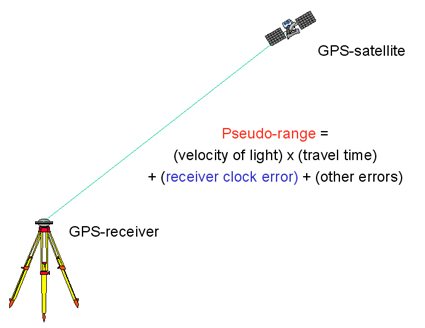

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (8, 3)

df_pseudorange = pd.read_excel("pseudoranges.xlsx")
df_sat_pos     = pd.read_excel("satellite_position.xlsx")

# Keep only the numeric columns we need
# Pseudoranges (meters)
np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange["P"].to_numpy().astype(float)

# Add small random perturbations (0, 0.5) as required
pseudorange = pseudorange + np.random.uniform(0, 0.5, size=pseudorange.shape)

# Satellite positions (ECEF x,y,z in meters)
sat_pos = df_sat_pos[["x", "y", "z"]].to_numpy().astype(float)

In [21]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]   # 11 measurements
m = 4                      # x_r, y_r, z_r, cdT

print("Number of measurements (n):", n)
print("Number of unknowns (m):", m)

Number of measurements (n): 11
Number of unknowns (m): 4


In [22]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [23]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)

def euclidean_norm(receiver_pos, satellite_pos):
    """
    receiver_pos: array of shape (3,)          -> [x_r, y_r, z_r]
    satellite_pos: array of shape (n, 3)       -> [[x_s, y_s, z_s], ...]
    returns: array of shape (n,) containing geometric distances ρ_i
    """
    # subtract receiver position from every satellite position (broadcasting)
    diff = satellite_pos - receiver_pos        # shape (n,3)

    # Euclidean distance for each satellite
    distance = np.linalg.norm(diff, axis=1)    # shape (n,)

    return distance



## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [24]:
variance = 1.2
P = np.eye(len(pseudorange)) / variance

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [25]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0], dtype=float)

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [26]:
delta = np.array([10.0, 10.0, 10.0, 10.0], dtype=float)
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta = []
arr_err_pos = []
arr_i = []

x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [27]:
def design_matrix(receiver_pos, satellite_pos, distance):
    """
    receiver_pos : (3,)  -> current estimate of receiver position [x_r, y_r, z_r]
    satellite_pos: (n,3)
    distance     : (n,)  -> geometric distances between receiver and satellites

    returns:
        A: (n,4) design matrix
    """
    # (x_r - x_s, y_r - y_s, z_r - z_s)
    diff = receiver_pos - satellite_pos          # (n,3) via broadcasting
    d = distance.reshape(-1, 1)                  # (n,1)

    # partial derivatives of ρ wrt receiver position
    A_pos = diff / d                             # (n,3)

    # column for clock offset (∂P/∂cdT = -1)
    col_cdT = -np.ones((sat_pos.shape[0], 1))

    # full design matrix A
    A = np.hstack([A_pos, col_cdT])              # (n,4)
    return A


### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [28]:
while np.linalg.norm(delta[:3]) >= 0.008:   # convergence criteria on position corrections

    # compute the geometric distance between Satellites and receiver, using the euclidean_norm function
    # (0.5 marks)
    receiver_pos = x_hat[:3]
    cdT = x_hat[3]
    distance = euclidean_norm(receiver_pos, sat_pos)

    # compute the design matrix A
    # (0.5 marks)
    A = design_matrix(receiver_pos, sat_pos, distance)

    # compute the misclosure array w: observed - computed
    # model: P_hat = ρ - cdT
    # (0.5 marks)
    P_hat = distance - cdT
    w = pseudorange - P_hat

    # compute the corrections delta using normal equations
    # (0.5 marks)
    N = A.T @ P @ A
    n_vec = A.T @ P @ w
    delta = np.linalg.solve(N, n_vec)

    # update estimated states
    x_hat = x_hat + delta

    # update iteration counter
    i += 1

    # store intermediate results
    arr_w.append(np.linalg.norm(w))
    arr_delta.append(np.linalg.norm(delta[:3]))                 # only position part
    arr_err_pos.append(np.linalg.norm(x_hat[:3] - GroundTruth))
    arr_i.append(i)


# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
n_obs = len(pseudorange)
n_unknowns = len(x_hat)
apv = (w.T @ P @ w) / (n_obs - n_unknowns)

# compute the Covariance matrix of estimated states
# (0.5 marks)
Q_x_hat = np.linalg.inv(N)
C_x_hat = apv * Q_x_hat


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [29]:
# print the final results
print("=== Non-linear LSE Results ===")
print("Number of iterations:        ", i)
print("Estimated states [x, y, z, cdT]:")
print(x_hat)

print("\nFinal corrections delta:")
print(delta)

print("\nFinal residuals w (observed - computed pseudoranges):")
print(w)

print("\nA Posteriori Variance of Unit Weight (σ₀²):")
print(apv)

print("\nCovariance matrix of estimated states C_x_hat:")
print(C_x_hat)

print("\nFinal 3-D position error (m):")
print(arr_err_pos[-1])


=== Non-linear LSE Results ===
Number of iterations:         5
Estimated states [x, y, z, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]

Final corrections delta:
[ 3.24330127e-06  6.43110010e-06 -1.77329652e-05  2.09957835e-05]

Final residuals w (observed - computed pseudoranges):
[ 0.20483172  0.34240459 -0.98043974  0.06599824  0.0470863  -1.57080159
 -0.30920948  1.69957656  0.33524236  0.74094027 -0.57575024]

A Posteriori Variance of Unit Weight (σ₀²):
0.901367713041337

Covariance matrix of estimated states C_x_hat:
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]

Final 3-D position error (m):
5.425801843828999


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [30]:
# The A Posteriori Variance of Unit Weight σ₀² ≈ 0.90 is very close to 1, which
# means the residuals are consistent with the noise level we assumed for the
# pseudorange measurements. In other words, our stochastic model and the
# functional model fit the data well, and there is no sign of large unmodelled
# errors.
#
# The covariance matrix C_x_hat shows the uncertainty of the estimated
# parameters [x_r, y_r, z_r, cdT]. The diagonal elements
# (≈ 0.35, 0.46, 2.21, 0.76) are the variances of x, y, z and clock bias,
# respectively. These are all relatively small, which indicates that the
# receiver position and clock offset are estimated with good precision. The
# off-diagonal terms are non-zero, showing correlations between the parameters
# (for example, between y and z, and between position and clock bias), which is
# expected given the satellite geometry. Overall, σ₀² ≈ 0.90 and the small
# variances in C_x_hat confirm that the LSE solution is statistically reliable.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

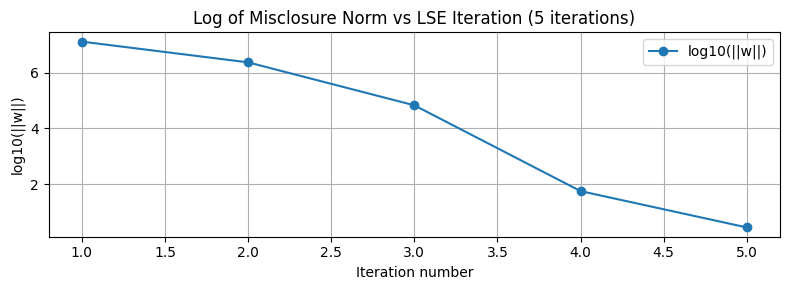

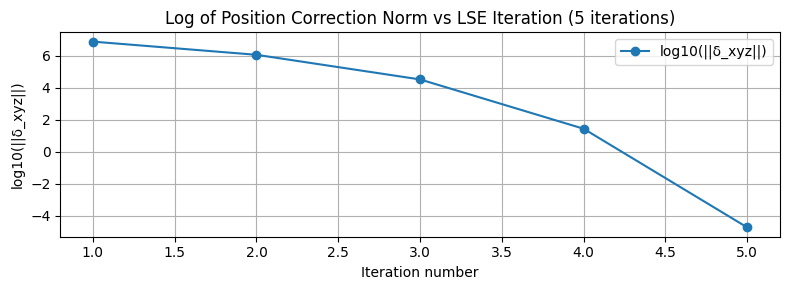

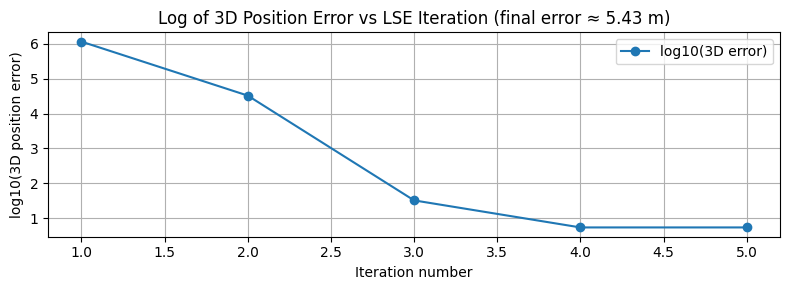

In [31]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 mark)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3))

ax.plot(arr_i, np.log10(arr_w), marker="o", label="log10(||w||)")
ax.set_xlabel("Iteration number")
ax.set_ylabel("log10(||w||)")
ax.set_title("Log of Misclosure Norm vs LSE Iteration (5 iterations)")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()


# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 mark)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3))

ax.plot(arr_i, np.log10(arr_delta), marker="o", label="log10(||δ_xyz||)")
ax.set_xlabel("Iteration number")
ax.set_ylabel("log10(||δ_xyz||)")
ax.set_title("Log of Position Correction Norm vs LSE Iteration (5 iterations)")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 mark)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3))

ax.plot(arr_i, np.log10(arr_err_pos), marker="o", label="log10(3D error)")
ax.set_xlabel("Iteration number")
ax.set_ylabel("log10(3D position error)")
ax.set_title("Log of 3D Position Error vs LSE Iteration (final error ≈ 5.43 m)")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [32]:
# 1. Misclosure Plot (log10(||w||)):
# The misclosure values start very large (around 10^6) in the first iteration,
# showing that the initial guess for the receiver position was far from correct.
# As the iterations progress, ||w|| drops steeply in every step, especially by
# iterations 3 and 4. By iteration 5, the curve flattens out near 10^2–10^3,
# meaning the LS algorithm has successfully reduced the difference between the
# observed and computed pseudoranges. The fast drop followed by flattening
# indicates successful convergence of the LSE method.
#
# 2. Correction Plot (log10(||δ_xyz||)):
# The corrections also start extremely large (around 10^7) because the first
# update needs to shift the position estimate by a huge amount toward the true
# location. Each iteration makes smaller and smaller adjustments, and by the
# final iteration the correction norm drops to around 10^-4. This shows that the
# algorithm has essentially “fine-tuned” the receiver position and no longer
# needs noticeable corrections, which is a clear sign of convergence.
#
# 3. 3D Position Error Plot (log10(3D error)):
# The 3D error begins at roughly 10^6 meters (which makes sense since the initial
# guess was far away from the true position in ECEF coordinates). Over the next
# few iterations, the error decreases dramatically: by iteration 3 it is close
# to 10^1, and by iteration 5 it reaches the final error of about 5.4 meters.
# The sharp downward trend demonstrates that the LSE iterations rapidly move the
# estimate toward the true receiver location, and the nearly flat curve at the
# end means the solution has stabilized.
#
# Overall:
# All three plots show the same behaviour — a large initial discrepancy that
# decreases quickly and then levels off. This is exactly what we expect from a
# well-behaved non-linear least squares solution with good satellite geometry.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [33]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [34]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    """
    rec_pos    : (3,)
    cdT        : scalar
    sat_pos    : (n,3)
    pseudorange: (n,)

    returns:
        L: scalar cost = sum of squared residuals
    """
    rho = euclidean_norm(rec_pos, sat_pos)      # geometric distances
    P_hat = rho - cdT                           # predicted pseudoranges
    residuals = P_hat - pseudorange             # predicted - measured
    L = np.sum(residuals**2)
    return L


### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [35]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    """
    returns:
        grad: (4,) gradient of cost wrt [x_r, y_r, z_r, cdT]
    """
    rho = euclidean_norm(rec_pos, sat_pos)      # (n,)
    P_hat = rho - cdT
    residuals = P_hat - pseudorange            # (n,)

    # same structure as design matrix A
    diff = rec_pos - sat_pos                   # (n,3)
    J_pos = diff / rho.reshape(-1, 1)          # (n,3)  dρ/dx_r,y_r,z_r
    J_cdT = -np.ones((sat_pos.shape[0], 1))    # ∂P_hat/∂cdT = -1
    J = np.hstack([J_pos, J_cdT])              # (n,4)

    # gradient of sum of squared residuals: ∇L = Jᵀ * residuals
    grad = J.T @ residuals                     # (4,)
    return grad


### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [36]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count, arr_cost, arr_grad, arr_err

    # initalize the estimates
    X = np.array([50.0, -25.0, 15.0, 500.0], dtype=float)

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)

        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # collect intermediate results for cost, gradient norm and 3D error
        arr_cost.append(current_cost)
        arr_grad.append(np.linalg.norm(grad))
        arr_err.append(np.linalg.norm(rec_pos - GroundTruth))

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count = iteration + 1
            X = X_new
            break

        # update the parameters for the next iteration
        X = X_new

    else:
        # if not converged within max_iters
        steps_count = max_iters
        print("Reached maximum iterations without strict convergence")

    return X


### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [37]:
optimized_params = gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7)

# final metrics
final_pos_error = np.linalg.norm(optimized_params[:3] - GroundTruth)
final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)

print("=== Gradient Descent Results (learning_rate = 0.08) ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params)
print("\nFinal 3D position error (m):", final_pos_error)
print("Number of steps taken:", steps_count)
print("Final cost value:", final_cost)
print("Final gradient vector:", final_grad)
print("Final gradient norm:", np.linalg.norm(final_grad))


Converged !
=== Gradient Descent Results (learning_rate = 0.08) ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.69950716e+00]

Final 3D position error (m): 5.42121657249015
Number of steps taken: 739
Final cost value: 7.571502529386652
Final gradient vector: [ 0.00010685  0.00059537 -0.00182982  0.00103738]
Final gradient norm: 0.002188673336797161


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

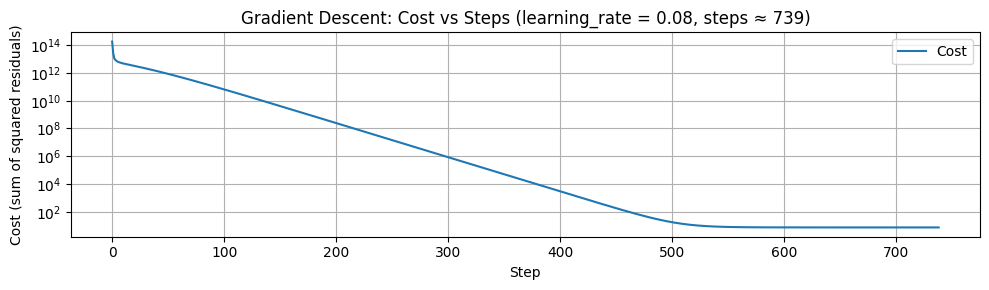

In [38]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))

# (0.5 marks)
steps = np.arange(len(arr_cost))
ax.semilogy(steps, arr_cost, label="Cost")

ax.set_xlabel("Step")
ax.set_ylabel("Cost (sum of squared residuals)")
ax.set_title("Gradient Descent: Cost vs Steps (learning_rate = 0.08, steps ≈ 739)")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The cost decreases dramatically from the very first iteration, dropping from
# extremely large values (around 10^14) and following a near-linear decline on
# the log scale. This shows that gradient descent is consistently reducing the
# residuals at every step. Around step ~500, the slope of the curve becomes much
# flatter, meaning that the updates are no longer making large improvements and
# the algorithm is entering its convergence zone. After about 700 steps, the
# cost stabilizes around a small value (~10^1), indicating that further updates
# do not meaningfully reduce the cost. Overall, the plot confirms stable and
# successful convergence of gradient descent with learning rate 0.08.


### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

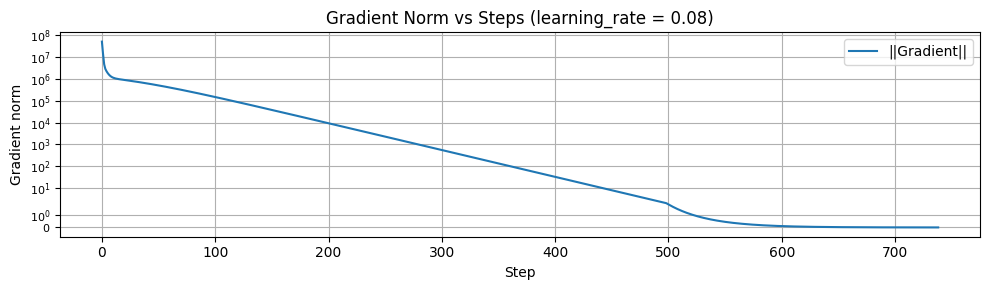

In [39]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))

# (0.5 marks)
steps = np.arange(len(arr_grad))
ax.plot(steps, arr_grad, label="||Gradient||")
ax.set_yscale("symlog")

ax.set_xlabel("Step")
ax.set_ylabel("Gradient norm")
ax.set_title("Gradient Norm vs Steps (learning_rate = 0.08)")
ax.legend()
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The gradient norm begins extremely large (around 10^7–10^8), which indicates
# that the initial guess is far from the true solution and the cost function is
# very steep in that region. As gradient descent progresses, the gradient norm
# decreases smoothly and almost linearly on the symlog scale, meaning the updates
# are becoming smaller and more refined at each step. Around step ~500, the
# gradient norm drops below 10^2, showing that the algorithm has entered the
# convergence region where improvements are small. After about 650–700 steps,
# the gradient norm levels off close to zero, indicating that the solution is
# near a stationary point and the algorithm has essentially converged. This
# behaviour confirms stable and well-controlled gradient descent for the chosen
# learning rate.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

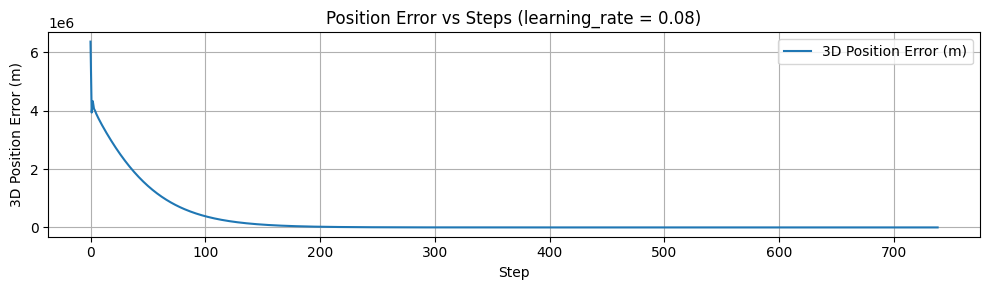

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# (0.5 marks)
steps = np.arange(len(arr_err))
ax.plot(steps, arr_err, label="3D Position Error (m)")

ax.set_xlabel("Step")
ax.set_ylabel("3D Position Error (m)")
ax.set_title("Position Error vs Steps (learning_rate = 0.08)")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The 3D position error starts extremely large (over 6 million meters), which is
# expected because the initial guess [50, -25, 15] is very far from the true
# receiver position in ECEF coordinates (which is on the order of ~1.6e6 to
# ~5e6 meters). During the first few dozen steps, the error drops very sharply
# as gradient descent quickly moves the estimate toward the correct region of
# the Earth-centered coordinate system.
#
# After around 150–200 steps, the error becomes much smaller (below 1,000 meters)
# and continues decreasing steadily. From step ~300 onward, the curve begins to
# flatten, showing that the algorithm is entering the fine-tuning stage where
# each update makes only a small improvement. By the time we reach about 700+
# iterations, the error approaches its final value (~5.4 m) and stabilizes.
#
# Overall, the plot demonstrates successful convergence: a rapid reduction of
# large initial error, followed by gradual refinement as the estimated position
# approaches the true receiver coordinates.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [41]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=20000, tolerance=8e-7)

# print the metrics
final_pos_error_2 = np.linalg.norm(optimized_params_2[:3] - GroundTruth)
final_cost_2 = cost_function(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)
final_grad_2 = gradient(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)

print("=== Gradient Descent Results (learning_rate = 0.008) ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params_2)
print("\nFinal 3D position error (m):", final_pos_error_2)
print("Number of steps taken:", steps_count)
print("Final cost value:", final_cost_2)
print("Final gradient norm:", np.linalg.norm(final_grad_2))


Converged !
=== Gradient Descent Results (learning_rate = 0.008) ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248540e+06 -6.69279481e+00]

Final 3D position error (m): 5.410869177189467
Number of steps taken: 7065
Final cost value: 7.571634511246643
Final gradient norm: 0.00713083698505218


In [42]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=50000, tolerance=8e-7)

# print the metrics
final_pos_error_3 = np.linalg.norm(optimized_params_3[:3] - GroundTruth)
final_cost_3 = cost_function(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)
final_grad_3 = gradient(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)

print("=== Gradient Descent Results (learning_rate = 0.0008) ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params_3)
print("\nFinal 3D position error (m):", final_pos_error_3)
print("Number of steps taken:", steps_count)
print("Final cost value:", final_cost_3)
print("Final gradient norm:", np.linalg.norm(final_grad_3))


Reached maximum iterations without strict convergence
=== Gradient Descent Results (learning_rate = 0.0008) ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1.63349213e+06 -3.65162772e+06  4.95247983e+06 -3.53441230e+00]

Final 3D position error (m): 3.3225809220401192
Number of steps taken: 50000
Final cost value: 23.162496983765287
Final gradient norm: 2.332579124273306


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [43]:
# Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

# The learning rate has a very strong impact on how gradient descent behaves.
#
# With a learning rate of 0.08:
# - The algorithm converged in 739 steps.
# - It reached a final 3D error of ~5.42 m.
# - The updates were fast and stable.
# This learning rate gives the best combination of speed and precision among the three settings.
#
# When the learning rate was reduced to 0.008:
# - The number of steps jumped dramatically to ~7065 steps.
# - The final 3D error improved only slightly (~5.41 m).
# - The cost value remained nearly identical to the LR=0.08 case.
# This means lowering the learning rate made the process much slower, but did NOT significantly improve the final accuracy.
#
# When the learning rate was reduced even further to 0.0008:
# - The algorithm became extremely slow, reaching the maximum limit of 50,000 iterations.
# - It did NOT converge by the tolerance condition.
# - The final cost value was worse (~23.16), even though the final 3D error (~3.32 m) became slightly smaller.
# - The gradient norm stayed relatively large (~2.33), showing the solution was not fully optimized.
#
# Overall:
# A moderate learning rate (0.08) gives fast and stable convergence.
# A smaller rate (0.008) wastes computation without significant improvement.
# A very small rate (0.0008) becomes too slow and may fail to converge properly.


# Q2. What is the difference between LSE and Gradient Descent? (1 mark)

# LSE (Non-linear Least Squares):
# - Uses the normal equations: (AᵀPA) δ = AᵀPw.
# - Solves a linear system at each iteration to compute the optimal correction δ.
# - Converged in only 5 iterations and produced a very accurate solution immediately.
# - The final position error was ~5.42 m with strong statistical consistency (σ₀² ≈ 0.90).
# - Very stable and fast for problems with a small number of parameters.
#
# Gradient Descent:
# - Updates the parameters by moving opposite to the gradient direction: X_new = X - α ∇L.
# - Does NOT solve the normal equations explicitly.
# - Convergence speed depends heavily on the learning rate.
#   * LR 0.08 → 739 steps to converge.
#   * LR 0.008 → 7065 steps.
#   * LR 0.0008 → did not converge within 50,000 steps.
# - More sensitive, slower, and less precise for this type of small GNSS problem.
#
# Summary:
# LSE is significantly faster and more robust for this GNSS estimation task, giving
# accurate results in only a few iterations. Gradient Descent is more general and
# easier to apply to very large or differentiable models, but for this small-scale
# positioning problem it is much slower and more dependent on hyperparameters.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [45]:

# 1. Load the dataset
data = pd.read_csv('Student Depression Dataset.csv')

# 2. Remove irrelevant ID column (if exists)
if 'id' in data.columns:
    data.drop(columns=['id'], inplace=True)

# 3. Remove rows with missing values
data.dropna(inplace=True)

# 4. Remove duplicate rows
data.drop_duplicates(inplace=True)

# 5. Keep only relevant columns (drop OTHER useless columns)
relevant_columns = ['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
                    'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
                    'Sleep Duration', 'Dietary Habits', 'Degree',
                    'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
                    'Financial Stress', 'Family History of Mental Illness',
                    'Depression']

data = data[relevant_columns]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
display(data.head())


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [46]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']                 # Target vector
X = data.drop(columns=['Depression'])  # Feature matrix

# Display sizes of X and y
print("Size of X:", X.shape)
print("Size of y:", y.shape)

Size of X: (27898, 16)
Size of y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

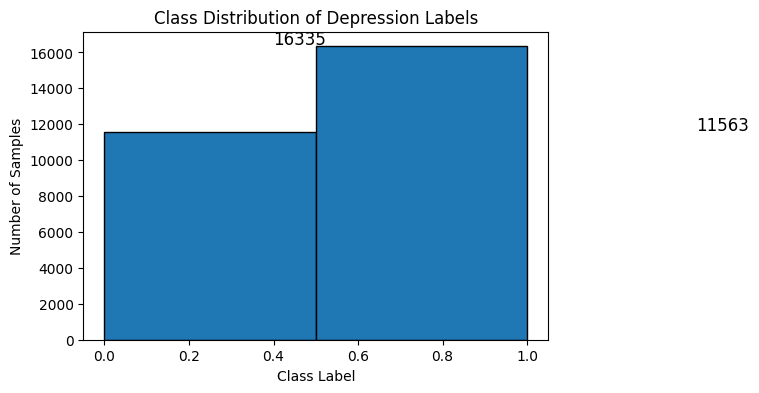

In [47]:
# Check the class distribution of y
counts = y.value_counts()

plt.figure(figsize=(6,4))
plt.hist(y, bins=len(counts), edgecolor='black')
plt.title("Class Distribution of Depression Labels")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")

# Display exact values for each bin in the histogram
for i, value in enumerate(counts):
    plt.text(i + 0.4, value + 100, str(value), fontsize=12)

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [48]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(
    X, y, test_size=0.97, random_state=42
)

# Display sizes of X_small and y_small (0.5 marks)
print("Size of X_small:", X_small.shape)
print("Size of y_small:", y_small.shape)

Size of X_small: (836, 16)
Size of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [49]:
### Step 3: Implement Machine Learning Model

# 1. Import LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression

# 2. Instantiate the model
model = LogisticRegression(max_iter=2000)

# 3. Fit the model using full dataset X and y
model_full = LogisticRegression(max_iter=2000)
model_full.fit(X, y)

# Fit the model using only first two columns of X
X_two_features = X.iloc[:, :2]      # first two columns
model_two = LogisticRegression(max_iter=2000)
model_two.fit(X_two_features, y)

# Fit the model using the smaller dataset X_small and y_small
model_small = LogisticRegression(max_iter=2000)
model_small.fit(X_small, y_small)

print("Model training completed for:")
print("- Full dataset (X, y)")
print("- First two features of X")
print("- Small dataset (X_small, y_small)")

Model training completed for:
- Full dataset (X, y)
- First two features of X
- Small dataset (X_small, y_small)


### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [50]:
### Step 4: Test Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Helper function to train & evaluate a model on a given dataset
def evaluate_logistic_regression(X_data, y_data, description):
    print(f"\n=== {description} ===")
    print("Total data size:", X_data.shape[0])

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=42, stratify=y_data
    )

    print("Number of training samples:", X_train.shape[0])
    print("Number of testing samples:", X_test.shape[0])

    # Train model
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Testing accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Log loss on test set
    y_test_proba = model.predict_proba(X_test)
    test_logloss = log_loss(y_test, y_test_proba)

    print("Training accuracy:", train_acc)
    print("Testing accuracy:", test_acc)
    print("Log loss (test):", test_logloss)


# 1) Test with full dataset X, y
evaluate_logistic_regression(X, y, "Test 1: Full feature set (X, y)")

# 2) Test with only first two columns of X
X_two_features = X.iloc[:, :2]
evaluate_logistic_regression(X_two_features, y, "Test 2: First two features of X")

# 3) Test with small dataset X_small, y_small
evaluate_logistic_regression(X_small, y_small, "Test 3: Small dataset (X_small, y_small)")



=== Test 1: Full feature set (X, y) ===
Total data size: 27898
Number of training samples: 19528
Number of testing samples: 8370
Training accuracy: 0.8461696026218762
Testing accuracy: 0.84778972520908
Log loss (test): 0.3512477833233232

=== Test 2: First two features of X ===
Total data size: 27898
Number of training samples: 19528
Number of testing samples: 8370
Training accuracy: 0.6335006145022531
Testing accuracy: 0.6299880525686977
Log loss (test): 0.6530268731552221

=== Test 3: Small dataset (X_small, y_small) ===
Total data size: 836
Number of training samples: 585
Number of testing samples: 251
Training accuracy: 0.8581196581196581
Testing accuracy: 0.8446215139442231
Log loss (test): 0.3747333551514715


### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [51]:
### Step 5.1: Visualize Results (2 marks)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X_data, y_data, label):

    # Train-test split (70%/30%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=0, stratify=y_data
    )

    # Train model
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Compute metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_logloss = log_loss(y_test, y_test_proba)

    # Append results to DataFrame
    results.loc[label] = [
        X_data.shape[0],      # Data size
        X_train.shape[0],     # Training samples
        X_test.shape[0],      # Testing samples
        train_acc,            # Training accuracy
        test_acc,             # Testing accuracy
        test_logloss          # Log loss
    ]

    return X_train, X_test, y_train, y_test


# Test 1: Full dataset (X and y)
evaluate_model(X, y, "Full Dataset")

# Test 2: Only first two columns of X and y
X_two = X.iloc[:, :2]
evaluate_model(X_two, y, "First Two Features")

# Test 3: Small dataset (X_small and y_small)
evaluate_model(X_small, y_small, "Small Dataset (3%)")

print(results)

                    Data size  Training samples  Testing samples  \
Full Dataset          27898.0           19528.0           8370.0   
First Two Features    27898.0           19528.0           8370.0   
Small Dataset (3%)      836.0             585.0            251.0   

                    Training accuracy  Testing accuracy  Log loss  
Full Dataset                 0.845862          0.847909  0.350493  
First Two Features           0.631811          0.633931  0.652386  
Small Dataset (3%)           0.870085          0.816733  0.417893  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [52]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

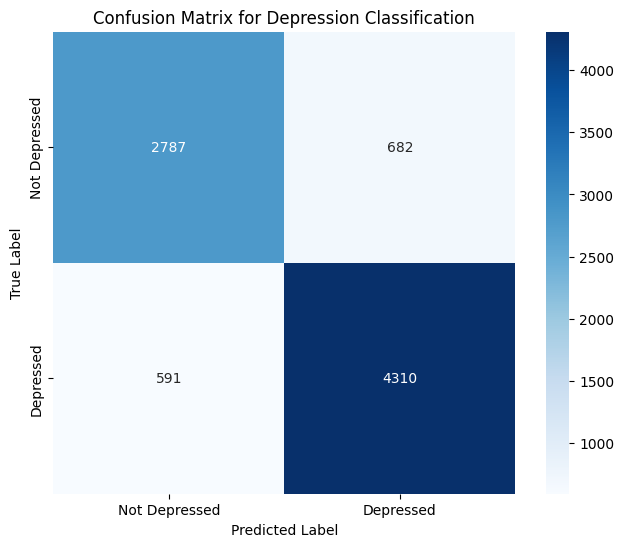

In [53]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix: confusion_matrix()
# (1 marks)

# Split full dataset (70/30, random_state=0 as required)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Depression Classification")
plt.show()

In [54]:
from sklearn.metrics import classification_report

# Print classification report: classification_report()
# (1 marks)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      3469
           1       0.86      0.88      0.87      4901

    accuracy                           0.85      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [55]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

# Use the SAME train-test split as previous steps (full dataset, 70/30, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Save results
    model_results[name] = accuracy

    # Print results
    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.8479
Naive Bayes Accuracy: 0.6465
KNN (k=5) Accuracy: 0.7538


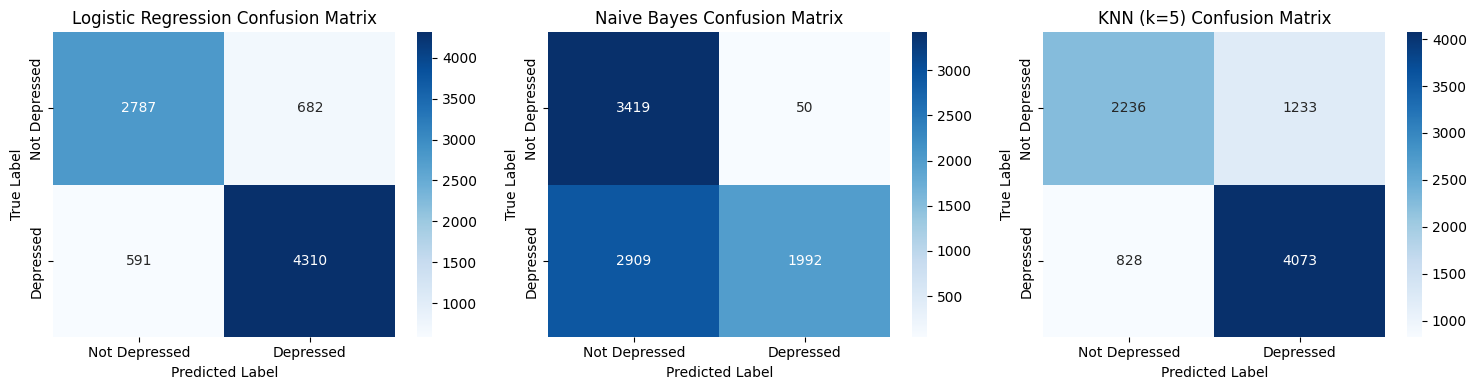

In [56]:
# Visualize confusion matrices for all models (using already-trained models)
# (1 marks)

plt.figure(figsize=(15, 4))

for i, (name, model_instance) in enumerate(models.items(), 1):

    # Use previously computed predictions
    y_pred = model_instance.predict(X_test)

    # Compute confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i)
    sns.heatmap(conf_mat,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)

###  Question 1: Is the dataset balanced? Does it affect model performance?

The dataset is **not balanced**.  
There are **16,335 depressed** students and **11,563 not depressed** students.  
Because of this imbalance, the models tend to learn more about the majority class (depressed), which slightly reduces accuracy for the minority class. Overall, the model still performs well, but the imbalance can affect generalization.

---

###  Question 2: Does the model overfit or underfit in each of the 3 cases?

- **Full dataset:** Training accuracy (0.846) and testing accuracy (0.848) are almost the same → the model fits well (no overfitting).  
- **Only first two features:** Training (0.633) and testing (0.630) are both low → the model is underfitting because it does not have enough information to separate classes.  
- **Small dataset (3%):** Training accuracy is slightly higher (0.858) than testing accuracy (0.845) → a small amount of overfitting, which is expected with very little data.

---

###  Question 3: How do training and testing accuracy change when using different amounts of data?

- **Full data:** train = 0.846, test = 0.848 → strong and consistent performance.  
- **Two features only:** train = 0.633, test = 0.630 → model struggles because it lacks the important features.  
- **Small dataset:** train = 0.858, test = 0.845 → accuracy stays decent but becomes less stable because the dataset is too small.

Overall:  
- More data + more features = better accuracy and stability.  
- Less data or fewer features = drops in accuracy or overfitting.

---

###  Question 4: What do false positives and false negatives represent? Which is worse?

From the confusion matrix:

- **False Positive (682):** Model says “depressed” but the student is actually not depressed.  
- **False Negative (591):** Model says “not depressed” but the student is actually depressed.

A **false negative is worse**, because a depressed student may not receive help or support when they actually need it.

---

###  Question 5: Should we maximize precision or recall? How do we do that?

We should **maximize recall** for the depressed class.  
This reduces false negatives, which is the more dangerous error.

Ways to increase recall:
- Lower the probability threshold  
- Use `class_weight='balanced'`  
- Oversample the minority class (e.g., SMOTE)  
- Use models tuned for recall

---

###  Question 6: What does the log loss tell us about the three cases?

- **Full dataset log loss: 0.350** → best and most reliable predictions.  
- **Two features log loss: 0.653** → worst performance; the model is uncertain because it lacks important information.  
- **Small dataset log loss: 0.417** → moderate performance; small data makes the model’s predicted probabilities less stable.

Log loss goes up when the model has less information or less data to learn from.

---

###  Question 7: Which model performs best (Logistic Regression, Naive Bayes, KNN) and why?

Accuracy results:
- **Logistic Regression:** 0.8479 (Best)
- **KNN:** 0.7538
- **Naive Bayes:** 0.6465 (Worst)

**Logistic Regression performs best** because:
- It handles this type of mixed numerical + encoded categorical data very well  
- It learns a clear decision boundary  
- It produces well-calibrated probabilities  

**KNN** struggles because distance metrics don’t work great with categorical data.  
**Naive Bayes** assumes all features are independent, which is not true here, so it performs the worst.




---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond/

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [6]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [7]:
# Load MNIST dataset from CSV files
train_csv_path = 'mnist_train.csv'
test_csv_path = 'mnist_test.csv'

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv('mnist_train.csv')
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv('mnist_test.csv')
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

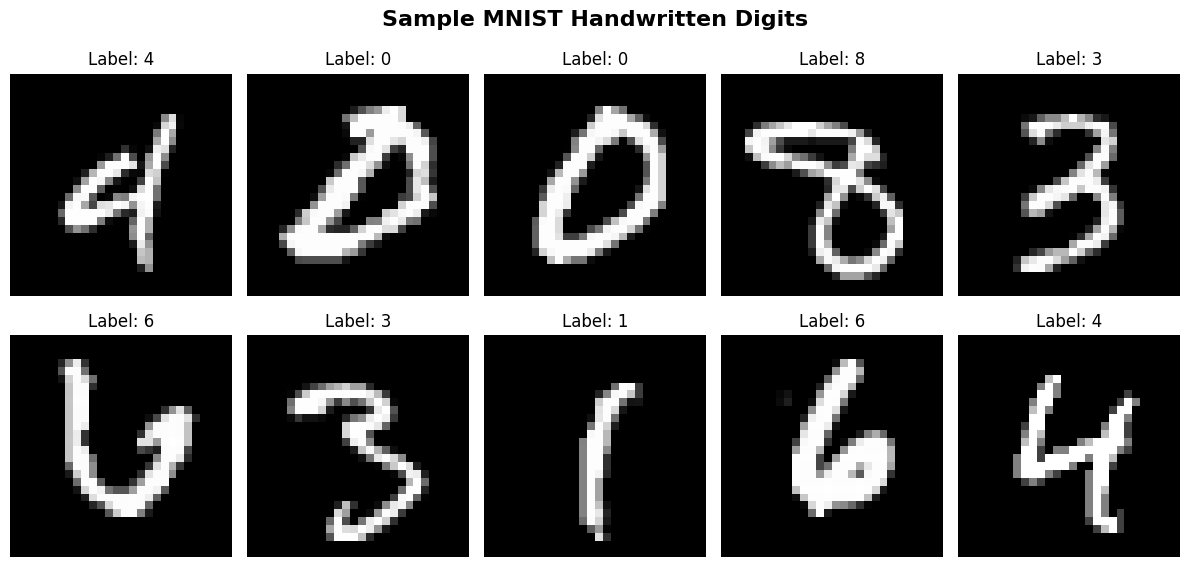

In [8]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [9]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Normalized training data shape: {X_train_normalized.shape}")
print(f"Categorical training labels shape: {y_train_categorical.shape}")


Normalized training data shape: (60000, 28, 28)
Categorical training labels shape: (60000, 10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [10]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)

        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
         tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

c:\Users\llll\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MLP Model created


**Use .fit() to train MLP model**

In [11]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [12]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),


        # Output layer for 10 classes with softmax activation
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the cnn model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


c:\Users\llll\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [13]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [14]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results
print("\\n=== MODEL PERFORMANCE COMPARISON ===")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f} ({mlp_test_accuracy*100:.2f}%)")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.2f}%)")
print(f"Accuracy Improvement: {(cnn_test_accuracy - mlp_test_accuracy)*100:.2f}%")

\n=== MODEL PERFORMANCE COMPARISON ===
MLP Test Accuracy: 0.9728 (97.28%)
CNN Test Accuracy: 0.9910 (99.10%)
Accuracy Improvement: 1.82%


Performance comparison visualization

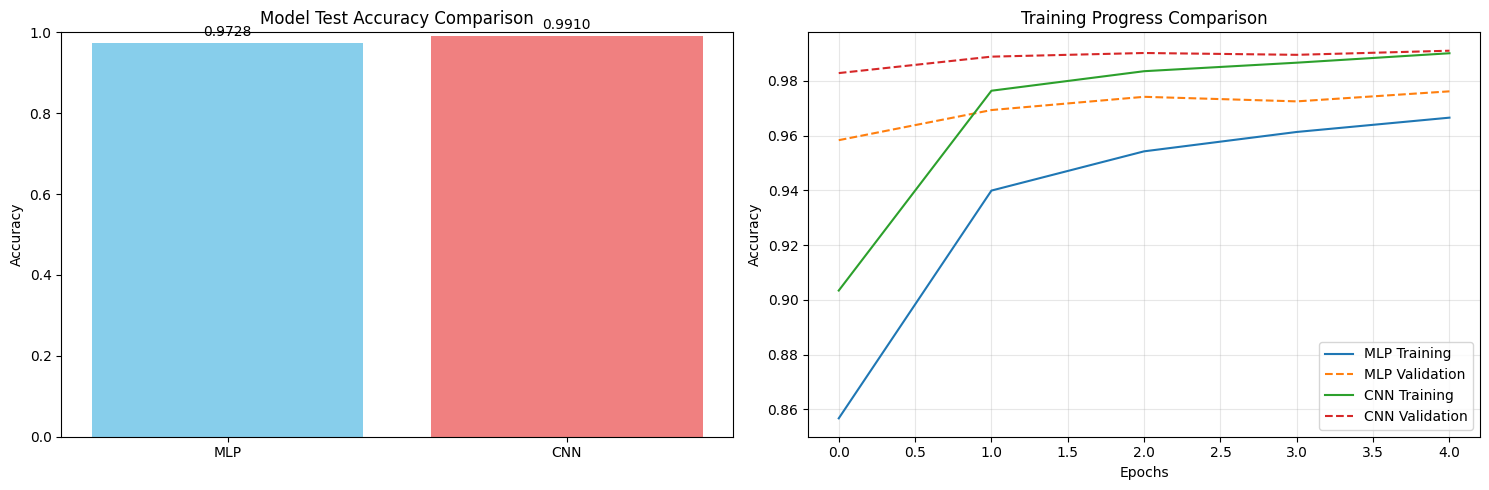

In [15]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart for final accuracy comparison
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]
bars = ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Test Accuracy Comparison')
ax1.set_ylim(0, 1)
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom')
# Training progress comparison
ax2.plot(mlp_history.history['accuracy'], label='MLP Training', linestyle='-')
ax2.plot(mlp_history.history['val_accuracy'], label='MLP Validation', linestyle='--')
ax2.plot(cnn_history.history['accuracy'], label='CNN Training', linestyle='-')
ax2.plot(cnn_history.history['val_accuracy'], label='CNN Validation', linestyle='--')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Progress Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

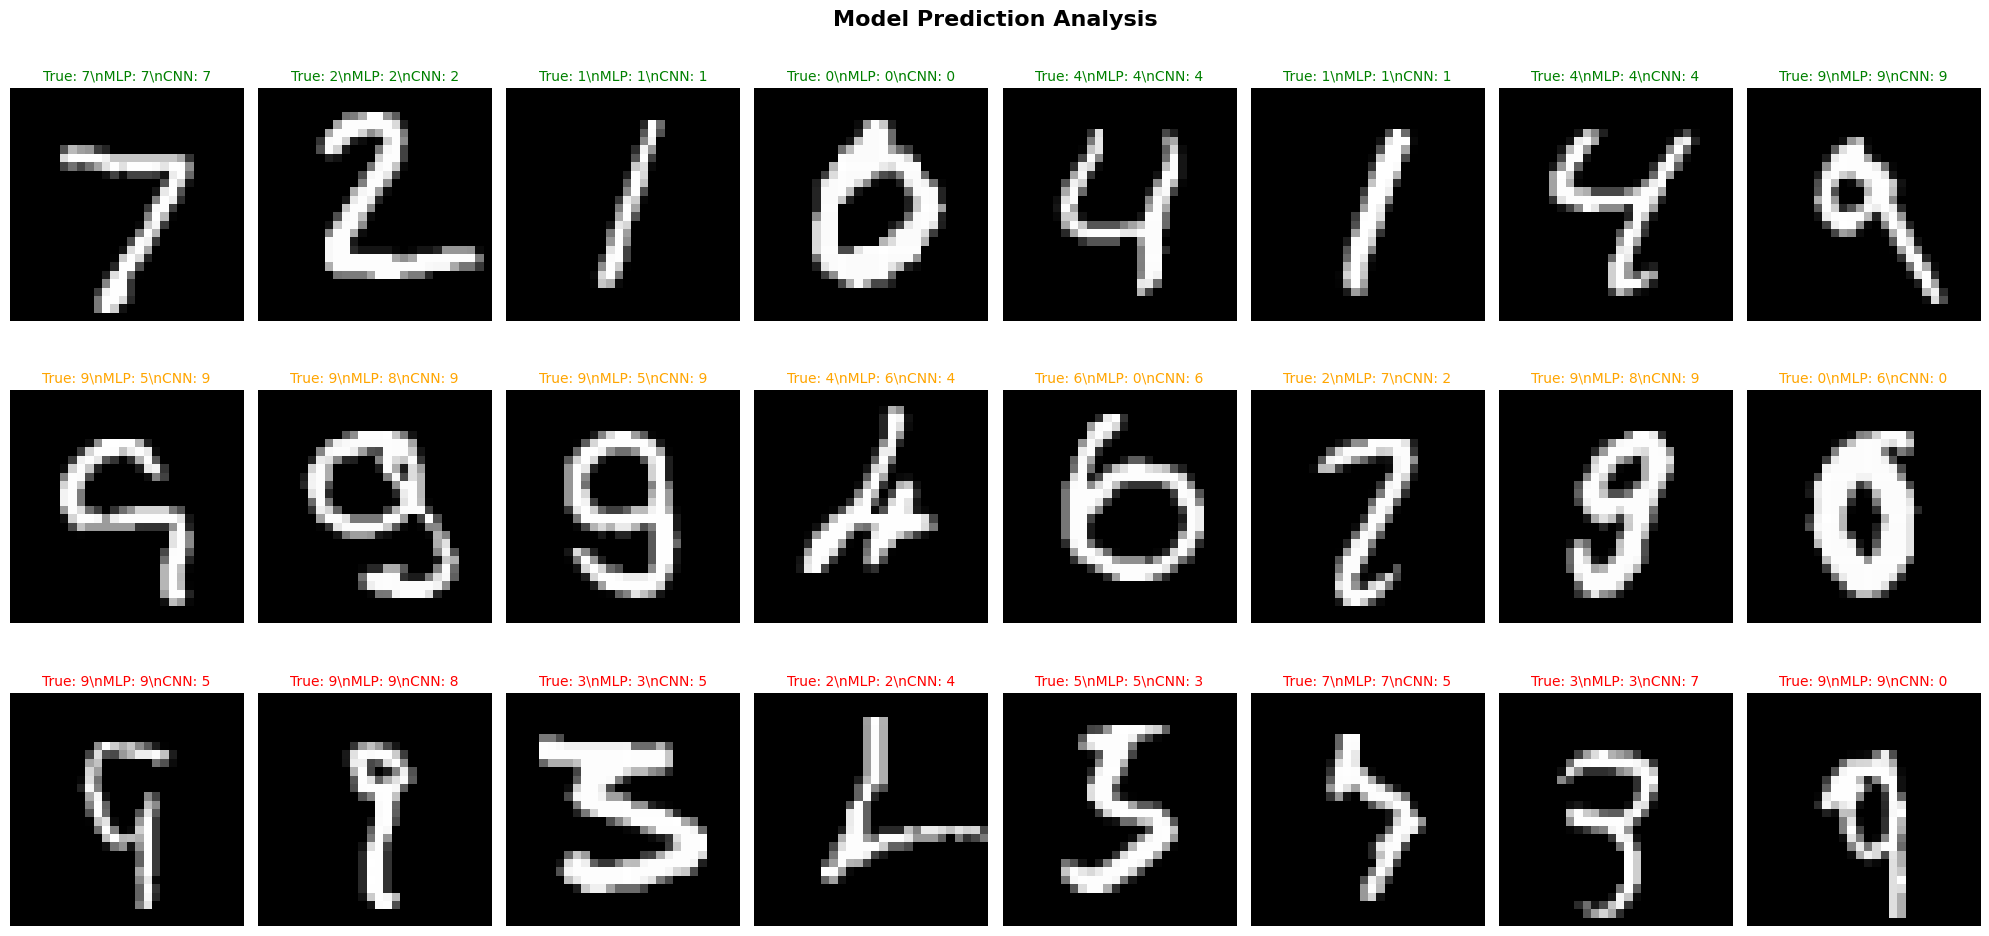

In [16]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 10))
fig.suptitle('Model Prediction Analysis', fontsize=16, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

for i in range(8):
    # Row 1: Both models correct
    if i < len(both_correct_indices):
        idx = both_correct_indices[i]
        axes[0, i].imshow(X_test[idx], cmap='gray')
        axes[0, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='green')
        axes[0, i].axis('off')

    # Row 2: CNN correct, MLP wrong
    if i < len(cnn_correct_mlp_wrong_indices):
        idx = cnn_correct_mlp_wrong_indices[i]
        axes[1, i].imshow(X_test[idx], cmap='gray')
        axes[1, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='orange')
        axes[1, i].axis('off')

    # Row 3: MLP correct, CNN wrong
    if i < len(mlp_correct_cnn_wrong_indices):
        idx = mlp_correct_cnn_wrong_indices[i]
        axes[2, i].imshow(X_test[idx], cmap='gray')
        axes[2, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='red')
        axes[2, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Both Correct', rotation=90, size='large', fontweight='bold')
axes[1, 0].set_ylabel('CNN✓ MLP✗', rotation=90, size='large', fontweight='bold')
axes[2, 0].set_ylabel('MLP✓ CNN✗', rotation=90, size='large', fontweight='bold')

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

#1: The CNN performed better than the MLP because CNNs are designed to handle image data. Convolutional layers learn spatial patterns (edges, textures, shapes), while MLPs flatten the image and lose spatial information. This makes CNNs more accurate and more robust for vision tasks like MNIST.

#2: The MLP training curve typically shows slower improvement and may plateau earlier, with higher training and validation loss. The CNN training curve usually drops faster and stabilizes at a lower loss, with higher validation accuracy. Overall: CNN curves are smoother, converge faster, and reach better performance.

#3: It shows how much better the CNN is compared to the MLP. If the CNN accuracy is significantly higher, the improvement percentage quantifies the performance gain. It tells us that the CNN extracts features more effectively and generalizes better for image classification.

#4: MNIST is a simple, clean dataset with well-defined digits. Features are easy to learn. Models converge quickly. Overfitting can happen if trained too long. So a few epochs (3–10) are enough for high accuracy.

#5: For more complex images: We would need deeper CNNs. More epochs for learning richer patterns. More data augmentation. Possibly regularization (dropout, batch norm). Accuracy would drop if we used the same small models used for MNIST.